In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("GPU Available:", tf.config.list_physical_devices('GPU'))


2026-02-09 22:17:51.053346: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 22:17:51.322238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-09 22:17:52.688701: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Dropout(0.25),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.25),
    Dense(1, activation="sigmoid")   # Binary output
])


/home/coco/Workspace/ai_ml/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770655676.421840   43838 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4130 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,635,361 (21.50 MB)

 Trainable params: 5,635,361 (21.50 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def train_generator(path):
    gen = ImageDataGenerator(
        rescale=1/255,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True
    )
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary"
    )



In [5]:
def test_generator(path):
    gen = ImageDataGenerator(rescale=1/255)
    return gen.flow_from_directory(
        path,
        target_size=(224,224),
        batch_size=32,
        class_mode="binary",
        shuffle=False   # IMPORTANT
    )


In [6]:
trainingData   = train_generator("data/Training")
validationData = test_generator("data/Validation")
testingData    = test_generator("data/Testing")

print("Class indices:", trainingData.class_indices)



Found 5712 images belonging to 2 classes.
Found 645 images belonging to 2 classes.
Found 666 images belonging to 2 classes.
Class indices: {'notumor': 0, 'tumor': 1}


In [7]:
es = EarlyStopping(
    monitor="val_recall",
    patience=4,
    mode="max",
    verbose=1,
    restore_best_weights=True
)

mc = ModelCheckpoint(
    filepath="./bestModel.keras",
    monitor="val_recall",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [8]:
class_weight = {
    0: 1.0,   # notumor
    1: 3.0    # tumor
}



In [9]:
history = model.fit(
    trainingData,
    epochs=30,
    validation_data=validationData,
    callbacks=[es, mc],
    class_weight=class_weight
)


Epoch 1/30


2026-02-09 22:18:04.425331: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f08f000d570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-09 22:18:04.425354: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-09 22:18:04.475537: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-09 22:18:04.883798: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-09 22:18:05.024351: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-09 22:18:05.

  2/179 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 1.6993 - precision: 0.7033 - recall: 0.7362 

I0000 00:00:1770655694.270890   43999 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.7478 - precision: 0.7966 - recall: 0.9743
Epoch 1: val_recall improved from None to 0.93527, saving model to ./bestModel.keras

Epoch 1: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 53s 236ms/step - loss: 0.4532 - precision: 0.8561 - recall: 0.9823 - val_loss: 0.2309 - val_precision: 0.9332 - val_recall: 0.9353
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.2236 - precision: 0.9281 - recall: 0.9834
Epoch 2: val_recall did not improve from 0.93527
179/179 ━━━━━━━━━━━━━━━━━━━━ 33s 183ms/step - loss: 0.2191 - precision: 0.9336 - recall: 0.9837 - val_loss: 0.1947 - val_precision: 0.9902 - val_recall: 0.9040
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 0.2160 - precision: 0.9368 - recall: 0.9821
Epoch 3: val_recall improved from 0.93527 to 0.98661, saving model to ./bestModel.keras

Epoch 3: finished saving model to ./bestModel.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step -

In [12]:
model = load_model("./bestModel.keras")

y_true = testingData.classes
y_prob = model.predict(testingData)


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


In [13]:
THRESHOLD = 0.3
y_pred = (y_prob >= THRESHOLD).astype(int).ravel()

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_true, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred,
    target_names=testingData.class_indices.keys()
))



CONFUSION MATRIX
[[108 100]
 [  4 454]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     notumor       0.96      0.52      0.68       208
       tumor       0.82      0.99      0.90       458

    accuracy                           0.84       666
   macro avg       0.89      0.76      0.79       666
weighted avg       0.86      0.84      0.83       666



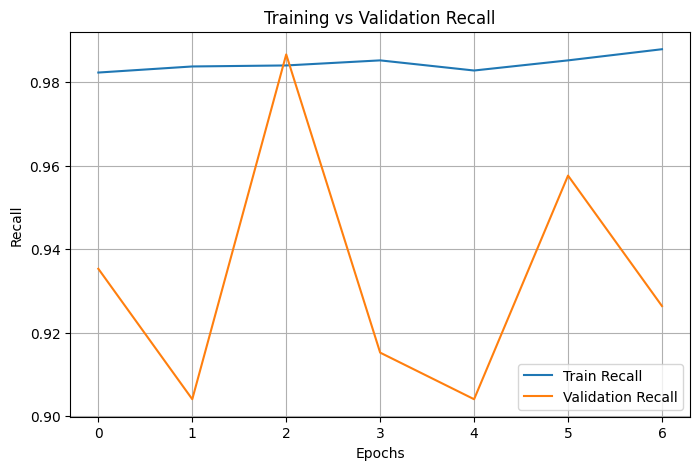

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall')
plt.legend()
plt.grid(True)
plt.show()


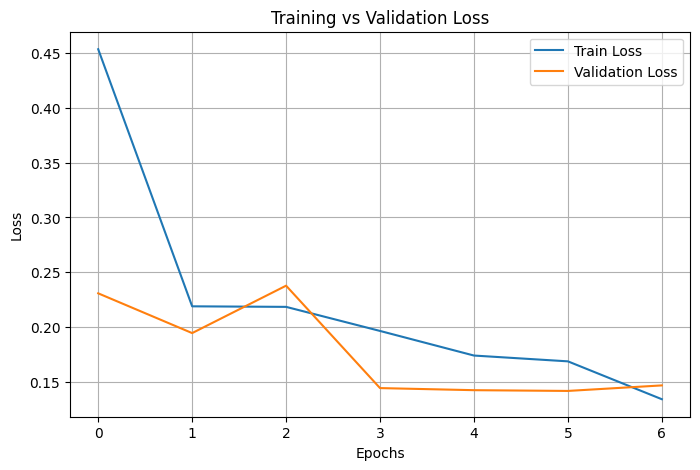

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


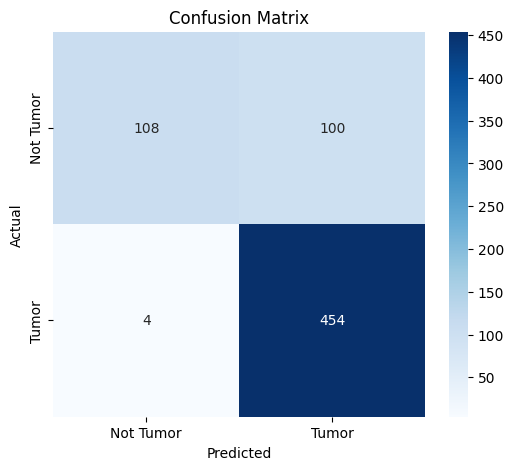

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Tumor', 'Tumor'],
            yticklabels=['Not Tumor', 'Tumor'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


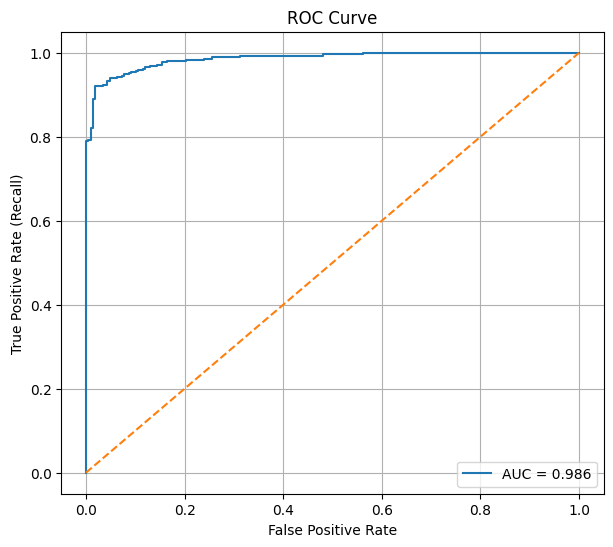

In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
